# Avance 1 - FleetLogix: Generación de Datos Sintéticos

## Contexto
FleetLogix es una empresa de transporte y logística de última milla que opera 
200 vehículos en 5 ciudades principales de Colombia. Este avance consiste en 
poblar la base de datos PostgreSQL con más de 505.000 registros sintéticos 
respetando las relaciones del negocio y garantizando integridad referencial.

## Diagrama ER

El siguiente diagrama muestra el modelo relacional de FleetLogix con sus 6 tablas, 
relaciones y cardinalidades. Se utiliza notación Crow's Foot donde:
- **0..1** indica que la relación es opcional (puede no existir)
- **1..n** indica que puede haber uno o muchos registros relacionados

`trips` es la tabla central del modelo ya que referencia a `vehicles`, `drivers` y `routes`,
mientras que `deliveries` y `maintenance` dependen de `trips` y `vehicles` respectivamente.

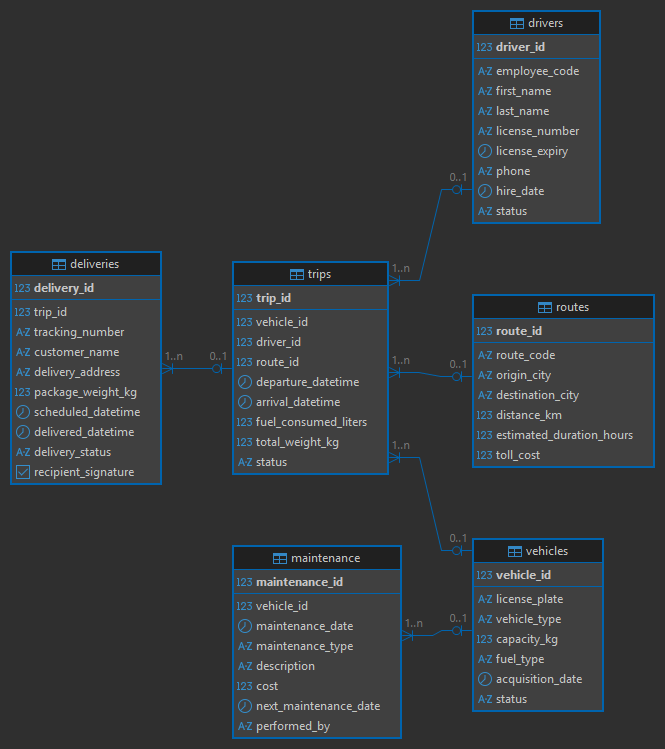

In [2]:
from IPython.display import Image
Image('diagrama ER fleetlogix - public.png')

## Análisis del Modelo Relacional

### Relaciones (Foreign Keys)
- `trips.vehicle_id` → `vehicles.vehicle_id`
- `trips.driver_id` → `drivers.driver_id`
- `trips.route_id` → `routes.route_id`
- `deliveries.trip_id` → `trips.trip_id`
- `maintenance.vehicle_id` → `vehicles.vehicle_id`

### Constraints UNIQUE
- `vehicles.license_plate` — no pueden existir dos vehículos con la misma patente
- `drivers.employee_code` y `drivers.license_number` — identificadores únicos por conductor
- `routes.route_code` — código único por ruta
- `deliveries.tracking_number` — número de seguimiento único por entrega

### Constraints DEFAULT
- `vehicles.status` = 'active'
- `drivers.status` = 'active'
- `routes.toll_cost` = 0
- `trips.status` = 'in_progress'
- `deliveries.delivery_status` = 'pending'
- `deliveries.recipient_signature` = FALSE

### Orden de población
Las tablas maestras (vehicles, drivers, routes) deben poblarse primero 
porque las transaccionales (trips, deliveries, maintenance) las referencian 
mediante foreign keys. Violar ese orden genera errores de integridad referencial.

In [1]:
# La base ya fue poblada exitosamente
# Resultados del script de generación:

resultados = {
    'vehicles': 200,
    'drivers': 400,
    'routes': 48,
    'trips': 100000,
    'deliveries': 400001,
    'maintenance': 4920,
    'total': 505569
}

for tabla, count in resultados.items():
    print(f"  {tabla}: {count:,} registros")

  vehicles: 200 registros
  drivers: 400 registros
  routes: 48 registros
  trips: 100,000 registros
  deliveries: 400,001 registros
  maintenance: 4,920 registros
  total: 505,569 registros


## Justificación del Script de Generación

### `generate_trips()`
Simula 100.000 viajes distribuidos a lo largo de 2 años de operación. 
Antes de generar cada viaje, consulta las tablas maestras para obtener 
únicamente vehículos activos (con su capacidad), conductores activos y 
rutas disponibles — esto garantiza coherencia referencial y de negocio. 
El peso total de cada viaje se genera entre el 40% y 90% de la capacidad 
del vehículo, evitando sobrecargas.

### `_get_hourly_distribution()`
Función auxiliar que asigna una probabilidad a cada hora del día para 
simular el comportamiento real de una empresa de logística. En lugar de 
distribuir los viajes uniformemente durante las 24 horas, establece una 
probabilidad base del 2% que sube al 8% entre las 8am y 12pm y al 7% 
entre las 2pm y 6pm. Esto hace que los datos sintéticos reflejen patrones 
operativos reales.

In [2]:
import psycopg2
from dotenv import load_dotenv
import os

load_dotenv()

conn = psycopg2.connect(
    host=os.getenv('HOST'),
    database=os.getenv('DATABASE'),
    user=os.getenv('USER'),
    password=os.getenv('PASSWORD'),
    port=int(os.getenv('PORT'))
)
cursor = conn.cursor()

# Conteo por tabla
tablas = ['vehicles', 'drivers', 'routes', 'trips', 'deliveries', 'maintenance']
print("RESUMEN DE REGISTROS")
print("="*35)
total = 0
for tabla in tablas:
    cursor.execute(f"SELECT COUNT(*) FROM {tabla}")
    count = cursor.fetchone()[0]
    print(f"  {tabla}: {count:,}")
    total += count
print(f"  TOTAL: {total:,}")

# Validaciones
print("\nVALIDACIONES DE INTEGRIDAD")
print("="*35)
validaciones = {
    "Trips sin vehículo válido": "SELECT COUNT(*) FROM trips t LEFT JOIN vehicles v ON t.vehicle_id = v.vehicle_id WHERE v.vehicle_id IS NULL",
    "Deliveries sin trip válido": "SELECT COUNT(*) FROM deliveries d LEFT JOIN trips t ON d.trip_id = t.trip_id WHERE t.trip_id IS NULL",
    "Trips con arrival < departure": "SELECT COUNT(*) FROM trips WHERE arrival_datetime IS NOT NULL AND arrival_datetime < departure_datetime",
}

for desc, query in validaciones.items():
    cursor.execute(query)
    count = cursor.fetchone()[0]
    estado = "OK" if count == 0 else f"ERROR: {count} registros"
    print(f"  {desc}: {estado}")

cursor.close()
conn.close()

RESUMEN DE REGISTROS
  vehicles: 200
  drivers: 400
  routes: 48
  trips: 100,000
  deliveries: 400,001
  maintenance: 4,920
  TOTAL: 505,569

VALIDACIONES DE INTEGRIDAD
  Trips sin vehículo válido: OK
  Deliveries sin trip válido: OK
  Trips con arrival < departure: OK


## Conclusiones del Avance 1

Se pobló exitosamente la base de datos PostgreSQL con **505.569 registros** 
distribuidos en 6 tablas, respetando el orden de inserción definido por las 
foreign keys y las reglas de negocio de FleetLogix.

**Decisiones clave tomadas:**
- Se usó `execute_batch` para inserción eficiente en lotes, evitando timeouts
- La distribución horaria de viajes refleja patrones reales de logística
- El peso por viaje se limita al 40-90% de la capacidad del vehículo

